Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3085 - Inteligencia Artificial - sección 10  

Cristian Túnchez (231359)  
Nadissa Vela (23764)

---

# Proyecto 2

## Task 1 - Configuración Segura de la Red (CSP y Factor Graphs)

### 1. Imports y Setup

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import time
import random
from collections import defaultdict

random.seed(42)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2. Modelado Formal

#### Definición del CSP

El problema de coloración de grafos para asignación de protocolos de seguridad se modela formalmente como un **Constraint Satisfaction Problem (CSP)** con los siguientes componentes:

**Variables:**  

$ X = \{S_1, S_2, \ldots, S_n\} $  

donde cada $S_i$ representa un servidor de la red ($ n \in [15, 20] $).

**Dominios:**  

$ D_i = \{\text{Rojo}, \text{Verde}, \text{Azul}, \text{Amarillo}\} \quad \forall i $  

Cada servidor puede tener asignado uno de 4 protocolos de seguridad.

**Restricciones:**  
$ C = \{(S_i, S_j) : S_i \text{ y } S_j \text{ están conectados} \Rightarrow \text{protocolo}(S_i) \neq \text{protocolo}(S_j)\} $  

Ningún par de servidores adyacentes (conectados directamente) puede compartir el mismo protocolo.

---

#### Factor Graph

Un **Factor Graph** representa las relaciones entre variables y restricciones como un grafo bipartito:

- **Nodos de variable:** Uno por cada servidor $S_i$.
- **Nodos de factor:** Uno por cada restricción binaria $(S_i, S_j)$.
- **Aristas:** Conectan cada factor con las dos variables que involucra.

$$G_F = (V \cup F, E)$$

donde $V$ = nodos de variables, $F$ = nodos de factores, y $E$ conecta cada factor $f_{ij} \in F$ con $S_i$ y $S_j$.

### 3. Generación del Grafo Aleatorio (15-20 nodos)

Grafo generado: 18 nodos, 56 aristas
Grado promedio: 6.22
Grado máximo  : 9


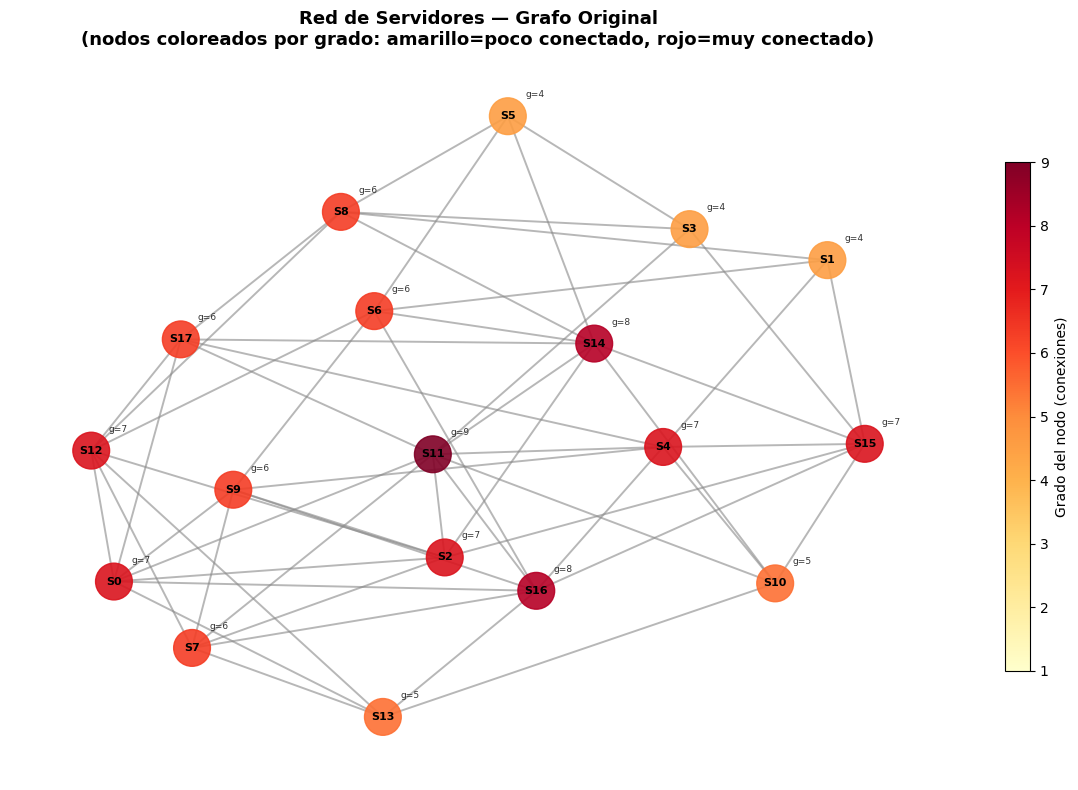

In [37]:
def generar_grafo(n_nodos=18, probabilidad_arista=0.35, seed=88):
    """
    Genera un grafo aleatorio conectado para representar la red de servidores.
    
    Args:
        n_nodos: Número de servidores (15-20)
        probabilidad_arista: Probabilidad de que exista una arista entre dos nodos
        seed: Semilla para reproducibilidad
    
    Returns:
        G: Grafo NetworkX
        vecinos: Diccionario {nodo: lista de vecinos}
    """
    random.seed(seed)
    np.random.seed(seed)
    
    G = nx.erdos_renyi_graph(n=n_nodos, p=probabilidad_arista, seed=seed)
    
    # Garantizar conectividad
    componentes = list(nx.connected_components(G))
    while len(componentes) > 1:
        u = random.choice(list(componentes[0]))
        v = random.choice(list(componentes[1]))
        G.add_edge(u, v)
        componentes = list(nx.connected_components(G))
    
    mapping = {i: f"S{i}" for i in range(n_nodos)}
    G = nx.relabel_nodes(G, mapping)
    vecinos = {nodo: list(G.neighbors(nodo)) for nodo in G.nodes()}
    
    print(f"Grafo generado: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    print(f"Grado promedio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
    print(f"Grado máximo  : {max(dict(G.degree()).values())}")
    return G, vecinos

G, vecinos = generar_grafo(n_nodos=18, probabilidad_arista=0.35)

# ── Visualización del grafo original ──────────────────────────────────────────
# kamada_kawai produce posiciones más estables y legibles que spring_layout
pos = nx.kamada_kawai_layout(G)

grados = dict(G.degree())
max_grado = max(grados.values())

# Colorear nodos por grado: cuanto más rojo, más conexiones (más difícil de colorear)
cmap = plt.get_cmap("YlOrRd")
colores_grado = [cmap(grados[n] / max_grado) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_color=colores_grado, node_size=700, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='#888888', width=1.4, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Anotaciones de grado junto a cada nodo
for nodo, (x, y) in pos.items():
    ax.annotate(f"g={grados[nodo]}", xy=(x, y), xytext=(x + 0.03, y + 0.06),
                fontsize=6.5, color='#333333')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max_grado))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Grado del nodo (conexiones)", shrink=0.7)

ax.set_title("Red de Servidores — Grafo Original\n"
             "(nodos coloreados por grado: amarillo=poco conectado, rojo=muy conectado)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 4. Clase CSP

In [38]:
class CSP:
    """
    Representa un Constraint Satisfaction Problem de coloración de grafos.
    
    Atributos:
        variables  : Lista ordenada de servidores (nodos del grafo).
        dominios   : Diccionario {variable: lista de valores posibles}.
        vecinos    : Diccionario {variable: lista de variables relacionadas}.
        restricciones: Función que retorna True si (var1=val1, var2=val2) es válido.
    """

    def __init__(self, variables, dominios, vecinos):
        self.variables = list(variables)
        # Copiar dominios para no mutar el original
        self.dominios = {v: list(d) for v, d in dominios.items()}
        self.vecinos = vecinos
        # Restricción única: valores distintos entre vecinos
        self.restricciones = lambda v1, val1, v2, val2: val1 != val2

    def es_consistente(self, variable, valor, asignacion):
        """
        Verifica si asignar `valor` a `variable` es consistente con la asignación actual.
        Revisa que ningún vecino ya asignado tenga el mismo valor.
        """
        for vecino in self.vecinos[variable]:
            if vecino in asignacion and not self.restricciones(variable, valor, vecino, asignacion[vecino]):
                return False
        return True


# Instanciar el CSP con los datos del grafo generado
PROTOCOLOS = ['Rojo', 'Verde', 'Azul', 'Amarillo']

dominios_iniciales = {nodo: list(PROTOCOLOS) for nodo in G.nodes()}
csp = CSP(variables=sorted(G.nodes()), dominios=dominios_iniciales, vecinos=vecinos)

print(f"CSP creado:")
print(f"  Variables ({len(csp.variables)}): {csp.variables}")
print(f"  Dominios por variable: {PROTOCOLOS}")
print(f"  Restricciones: valores distintos entre servidores conectados")

CSP creado:
  Variables (18): ['S0', 'S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
  Dominios por variable: ['Rojo', 'Verde', 'Azul', 'Amarillo']
  Restricciones: valores distintos entre servidores conectados


### 5. Algoritmo Backtracking Search (Versión 1): Backtracking Puro

Asigna valores secuencialmente. Si se viola una restricción, retrocede a la variable anterior y prueba otro valor.

In [39]:
def backtracking_puro(csp):
    """
    Backtracking Search básico sin optimizaciones.
    
    - Selección de variables: secuencial (orden de csp.variables).
    - Sin propagación de restricciones (no hay forward checking).
    - Métricas registradas: asignaciones intentadas y backtracks.
    
    Returns:
        asignacion: Diccionario {variable: valor} con la solución, o None si no hay solución.
        metricas  : Diccionario con 'asignaciones' y 'backtracks'.
    """
    metricas = {'asignaciones': 0, 'backtracks': 0}

    def backtrack(asignacion):
        # Caso base: todas las variables asignadas
        if len(asignacion) == len(csp.variables):
            return asignacion

        # Selección secuencial: primera variable sin asignar
        variable = next(v for v in csp.variables if v not in asignacion)

        for valor in csp.dominios[variable]:
            metricas['asignaciones'] += 1

            if csp.es_consistente(variable, valor, asignacion):
                asignacion[variable] = valor
                resultado = backtrack(asignacion)
                if resultado is not None:
                    return resultado
                # Backtrack: eliminar asignación
                del asignacion[variable]

        # Ningún valor funcionó → backtrack
        metricas['backtracks'] += 1
        return None

    solucion = backtrack({})
    return solucion, metricas


# Ejecutar Backtracking Puro
t0 = time.perf_counter()
solucion_bp, metricas_bp = backtracking_puro(csp)
t1 = time.perf_counter()
tiempo_bp = (t1 - t0) * 1000  # convertir a ms

print("=== Backtracking Puro ===")
print(f"  Solución encontrada: {'Sí' if solucion_bp else 'No'}")
print(f"  Asignaciones intentadas: {metricas_bp['asignaciones']}")
print(f"  Backtracks           : {metricas_bp['backtracks']}")
print(f"  Tiempo de ejecución  : {tiempo_bp:.3f} ms")
if solucion_bp:
    print(f"  Solución: {solucion_bp}")

=== Backtracking Puro ===
  Solución encontrada: Sí
  Asignaciones intentadas: 2479
  Backtracks           : 609
  Tiempo de ejecución  : 6.977 ms
  Solución: {'S0': 'Rojo', 'S1': 'Rojo', 'S10': 'Verde', 'S11': 'Azul', 'S12': 'Azul', 'S13': 'Amarillo', 'S14': 'Rojo', 'S15': 'Azul', 'S16': 'Verde', 'S17': 'Verde', 'S2': 'Verde', 'S3': 'Rojo', 'S4': 'Amarillo', 'S5': 'Verde', 'S6': 'Amarillo', 'S7': 'Rojo', 'S8': 'Amarillo', 'S9': 'Azul'}


### 6. Algoritmo Backtracking Search (Versión 2): Backtracking + Forward Checking

Tras asignar una variable, elimina valores inconsistentes de los dominios de las variables vecinas no asignadas. Si algún dominio queda vacío, retrocede de inmediato.

In [40]:
def backtracking_fc(csp):
    """
    Backtracking con Forward Checking (Lookahead).
    
    - Selección de variables: secuencial (orden de csp.variables).
    - Forward Checking: tras asignar una variable, elimina valores inconsistentes
      de los dominios de sus vecinos no asignados. Si un dominio queda vacío,
      retrocede de inmediato sin explorar más ramas.
    - Restaura dominios al hacer backtrack (dominios locales por nivel).
    
    Returns:
        asignacion: Diccionario {variable: valor} con la solución, o None.
        metricas  : Diccionario con 'asignaciones' y 'backtracks'.
    """
    metricas = {'asignaciones': 0, 'backtracks': 0}

    dominios = {v: list(d) for v, d in csp.dominios.items()}

    def forward_check(variable, valor, asignacion, dominios):
        """
        Elimina `valor` de los dominios de los vecinos no asignados de `variable`.

        Siempre retorna (eliminados, fallo):
          - eliminados: lista de (vecino, valor) removidos hasta el momento del fallo
            (puede ser parcial si hubo fallo). Necesaria para restaurar en backtrack.
          - fallo: True si algún dominio quedó vacío.

        NOTA: retornar la lista parcial incluso en caso de fallo es crítico.
        Si se devolviera None y el caller omitiera la restauración, los dominios
        modificados antes del fallo quedarían corruptos para el resto de la búsqueda.
        """
        eliminados = []
        for vecino in csp.vecinos[variable]:
            if vecino not in asignacion:
                if valor in dominios[vecino]:
                    dominios[vecino].remove(valor)
                    eliminados.append((vecino, valor))
                if len(dominios[vecino]) == 0:
                    # Dominio vacío → fallo, pero devolvemos lo eliminado hasta aquí
                    return eliminados, True
        return eliminados, False

    def backtrack(asignacion, dominios):
        if len(asignacion) == len(csp.variables):
            return asignacion

        variable = next(v for v in csp.variables if v not in asignacion)

        for valor in list(dominios[variable]):
            metricas['asignaciones'] += 1

            if csp.es_consistente(variable, valor, asignacion):
                asignacion[variable] = valor
                eliminados, fallo = forward_check(variable, valor, asignacion, dominios)

                if not fallo:
                    resultado = backtrack(asignacion, dominios)
                    if resultado is not None:
                        return resultado

                # Restaurar SIEMPRE (tanto si hubo fallo como si no)
                for vecino, val_eliminado in eliminados:
                    dominios[vecino].append(val_eliminado)

                del asignacion[variable]

        metricas['backtracks'] += 1
        return None

    solucion = backtrack({}, dominios)
    return solucion, metricas


# Ejecutar Backtracking + Forward Checking
t0 = time.perf_counter()
solucion_fc, metricas_fc = backtracking_fc(csp)
t1 = time.perf_counter()
tiempo_fc = (t1 - t0) * 1000

print("=== Backtracking + Forward Checking ===")
print(f"  Solución encontrada: {'Sí' if solucion_fc else 'No'}")
print(f"  Asignaciones intentadas: {metricas_fc['asignaciones']}")
print(f"  Backtracks           : {metricas_fc['backtracks']}")
print(f"  Tiempo de ejecución  : {tiempo_fc:.3f} ms")
if solucion_fc:
    print(f"  Solución: {solucion_fc}")

=== Backtracking + Forward Checking ===
  Solución encontrada: Sí
  Asignaciones intentadas: 314
  Backtracks           : 186
  Tiempo de ejecución  : 9.430 ms
  Solución: {'S0': 'Rojo', 'S1': 'Rojo', 'S10': 'Verde', 'S11': 'Azul', 'S12': 'Azul', 'S13': 'Amarillo', 'S14': 'Rojo', 'S15': 'Azul', 'S16': 'Verde', 'S17': 'Verde', 'S2': 'Verde', 'S3': 'Rojo', 'S4': 'Amarillo', 'S5': 'Verde', 'S6': 'Amarillo', 'S7': 'Rojo', 'S8': 'Amarillo', 'S9': 'Azul'}


### 7. Algoritmo Backtracking Search (Versión 3): Backtracking + Forward Checking + MRV (Minimum Remaining Values)

Heurística de selección de variable. Elige siempre la variable no asignada con el dominio más pequeño, reduciendo el árbol de búsqueda.

In [41]:
def backtracking_fc_mrv(csp):
    """
    Backtracking con Forward Checking + heurística MRV (Minimum Remaining Values).
    
    - MRV: selecciona la variable no asignada con el menor número de valores
      restantes en su dominio (los dominios se reducen mediante forward checking).
      En caso de empate, elige la variable con mayor grado (más vecinos).
    - Forward Checking: igual que la versión anterior.
    
    Returns:
        asignacion: Diccionario {variable: valor} con la solución, o None.
        metricas  : Diccionario con 'asignaciones' y 'backtracks'.
    """
    metricas = {'asignaciones': 0, 'backtracks': 0}

    dominios = {v: list(d) for v, d in csp.dominios.items()}

    def seleccionar_variable_mrv(asignacion, dominios):
        """
        MRV: elige la variable no asignada con el dominio más pequeño.
        Desempate por grado (mayor número de vecinos no asignados).
        """
        no_asignadas = [v for v in csp.variables if v not in asignacion]
        return min(
            no_asignadas,
            key=lambda v: (
                len(dominios[v]),
                -sum(1 for n in csp.vecinos[v] if n not in asignacion)
            )
        )

    def forward_check(variable, valor, asignacion, dominios):
        """
        Elimina `valor` de los dominios de vecinos no asignados.
        
        Siempre retorna (eliminados, fallo) para garantizar que la restauración
        de dominios ocurra incluso cuando forward checking detecta un fallo parcial.
        """
        eliminados = []
        for vecino in csp.vecinos[variable]:
            if vecino not in asignacion:
                if valor in dominios[vecino]:
                    dominios[vecino].remove(valor)
                    eliminados.append((vecino, valor))
                if len(dominios[vecino]) == 0:
                    return eliminados, True
        return eliminados, False

    def backtrack(asignacion, dominios):
        if len(asignacion) == len(csp.variables):
            return asignacion

        variable = seleccionar_variable_mrv(asignacion, dominios)

        for valor in list(dominios[variable]):
            metricas['asignaciones'] += 1

            if csp.es_consistente(variable, valor, asignacion):
                asignacion[variable] = valor
                eliminados, fallo = forward_check(variable, valor, asignacion, dominios)

                if not fallo:
                    resultado = backtrack(asignacion, dominios)
                    if resultado is not None:
                        return resultado

                # Restaurar SIEMPRE (tanto si hubo fallo como si no)
                for vecino, val_eliminado in eliminados:
                    dominios[vecino].append(val_eliminado)

                del asignacion[variable]

        metricas['backtracks'] += 1
        return None

    solucion = backtrack({}, dominios)
    return solucion, metricas


# Ejecutar Backtracking + FC + MRV
t0 = time.perf_counter()
solucion_mrv, metricas_mrv = backtracking_fc_mrv(csp)
t1 = time.perf_counter()
tiempo_mrv = (t1 - t0) * 1000

print("=== Backtracking + Forward Checking + MRV ===")
print(f"  Solución encontrada: {'Sí' if solucion_mrv else 'No'}")
print(f"  Asignaciones intentadas: {metricas_mrv['asignaciones']}")
print(f"  Backtracks           : {metricas_mrv['backtracks']}")
print(f"  Tiempo de ejecución  : {tiempo_mrv:.3f} ms")
if solucion_mrv:
    print(f"  Solución: {solucion_mrv}")

=== Backtracking + Forward Checking + MRV ===
  Solución encontrada: Sí
  Asignaciones intentadas: 18
  Backtracks           : 0
  Tiempo de ejecución  : 0.750 ms
  Solución: {'S11': 'Rojo', 'S14': 'Verde', 'S2': 'Azul', 'S0': 'Verde', 'S16': 'Azul', 'S12': 'Rojo', 'S6': 'Amarillo', 'S13': 'Amarillo', 'S10': 'Azul', 'S9': 'Rojo', 'S7': 'Verde', 'S8': 'Azul', 'S17': 'Amarillo', 'S4': 'Verde', 'S1': 'Rojo', 'S15': 'Amarillo', 'S3': 'Verde', 'S5': 'Rojo'}


### 8. Validación de Soluciones

In [42]:
def validar_solucion(solucion, G):
    """
    Verifica que ningún par de servidores adyacentes tenga el mismo protocolo.
    
    Returns:
        True si la solución es válida, False en caso contrario.
    """
    if solucion is None:
        return False
    for u, v in G.edges():
        if solucion.get(u) == solucion.get(v):
            print(f"  CONFLICTO: {u} y {v} tienen el mismo protocolo ({solucion[u]})")
            return False
    return True

print("Validación de soluciones:")
for nombre, sol in [("Backtracking Puro", solucion_bp),
                    ("FC", solucion_fc),
                    ("FC + MRV", solucion_mrv)]:
    valida = validar_solucion(sol, G)
    print(f"  {nombre}: {'VÁLIDA ✓' if valida else 'INVÁLIDA ✗'}")

Validación de soluciones:
  Backtracking Puro: VÁLIDA ✓
  FC: VÁLIDA ✓
  FC + MRV: VÁLIDA ✓


### 9. Comparación de Métricas

Algoritmo                   Asignaciones   Backtracks   Tiempo (ms)
-------------------------------------------------------------------
Backtracking Puro                   2479          609         6.977
BT + FC                              314          186         9.430
BT + FC + MRV                         18            0         0.750


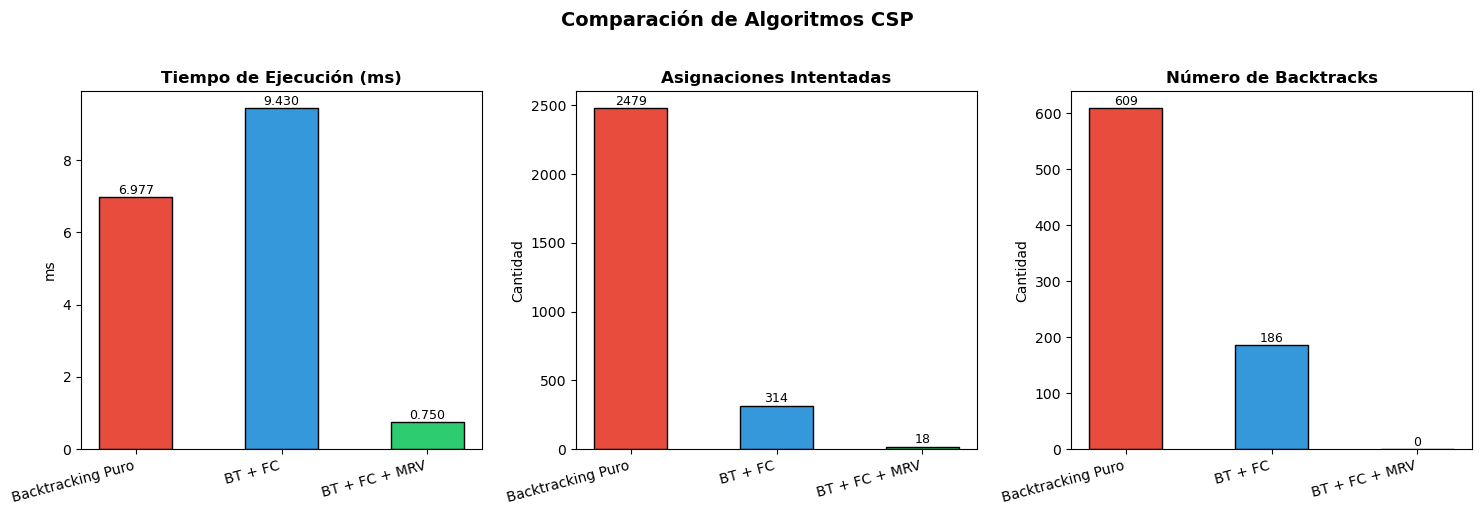

In [43]:
# ── Tabla comparativa ──────────────────────────────────────────────────────────
algoritmos   = ["Backtracking Puro", "BT + FC", "BT + FC + MRV"]
asignaciones = [metricas_bp['asignaciones'], metricas_fc['asignaciones'], metricas_mrv['asignaciones']]
backtracks   = [metricas_bp['backtracks'],   metricas_fc['backtracks'],   metricas_mrv['backtracks']]
tiempos      = [tiempo_bp, tiempo_fc, tiempo_mrv]

print(f"{'Algoritmo':<25} {'Asignaciones':>14} {'Backtracks':>12} {'Tiempo (ms)':>13}")
print("-" * 67)
for alg, asig, bt, t in zip(algoritmos, asignaciones, backtracks, tiempos):
    print(f"{alg:<25} {asig:>14} {bt:>12} {t:>13.3f}")

# ── Gráficos comparativos ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = ['#e74c3c', '#3498db', '#2ecc71']

# Gráfico 1: Tiempo de ejecución
axes[0].bar(algoritmos, tiempos, color=colores, edgecolor='black', width=0.5)
axes[0].set_title("Tiempo de Ejecución (ms)", fontweight='bold')
axes[0].set_ylabel("ms")
plt.setp(axes[0].get_xticklabels(), rotation=15, ha='right')
for i, v in enumerate(tiempos):
    axes[0].text(i, v + max(tiempos) * 0.01, f"{v:.3f}", ha='center', fontsize=9)

# Gráfico 2: Asignaciones intentadas
axes[1].bar(algoritmos, asignaciones, color=colores, edgecolor='black', width=0.5)
axes[1].set_title("Asignaciones Intentadas", fontweight='bold')
axes[1].set_ylabel("Cantidad")
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')
for i, v in enumerate(asignaciones):
    axes[1].text(i, v + max(asignaciones) * 0.01, str(v), ha='center', fontsize=9)

# Gráfico 3: Backtracks
axes[2].bar(algoritmos, backtracks, color=colores, edgecolor='black', width=0.5)
axes[2].set_title("Número de Backtracks", fontweight='bold')
axes[2].set_ylabel("Cantidad")
plt.setp(axes[2].get_xticklabels(), rotation=15, ha='right')
for i, v in enumerate(backtracks):
    axes[2].text(i, v + max(backtracks) * 0.01 if max(backtracks) > 0 else 0.1,
                 str(v), ha='center', fontsize=9)

plt.suptitle("Comparación de Algoritmos CSP", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10. Análisis

#### ¿Cuál algoritmo es más efectivo y por qué?

Los tres algoritmos resuelven correctamente el problema de coloración de grafos, pero difieren en eficiencia:

**Backtracking Puro** es el menos eficiente. Al no tener ningún mecanismo anticipatorio, explora muchas ramas del árbol de búsqueda que son inevitablemente inválidas. Sólo detecta conflictos cuando ya se han asignado las variables, lo que genera numerosas vueltas atrás.

**Backtracking + Forward Checking** mejora considerablemente el rendimiento. Al propagarse la restricción hacia adelante después de cada asignación, los dominios de las variables vecinas se reducen de inmediato. Si un dominio queda vacío, se detecta el fallo antes de seguir asignando variables, evitando explorar subárboles que no pueden conducir a soluciones.

**Backtracking + FC + MRV** es el más eficiente. La heurística MRV dirige la búsqueda hacia las variables más "restringidas" primero (las que tienen menos opciones disponibles) lo que reduce drásticamente el factor de ramificación efectivo del árbol. Además, los fallos se detectan más pronto, ya que las variables con dominios pequeños son las que tienen mayor riesgo de quedarse sin valores válidos.

### 11. Visualización de la Solución

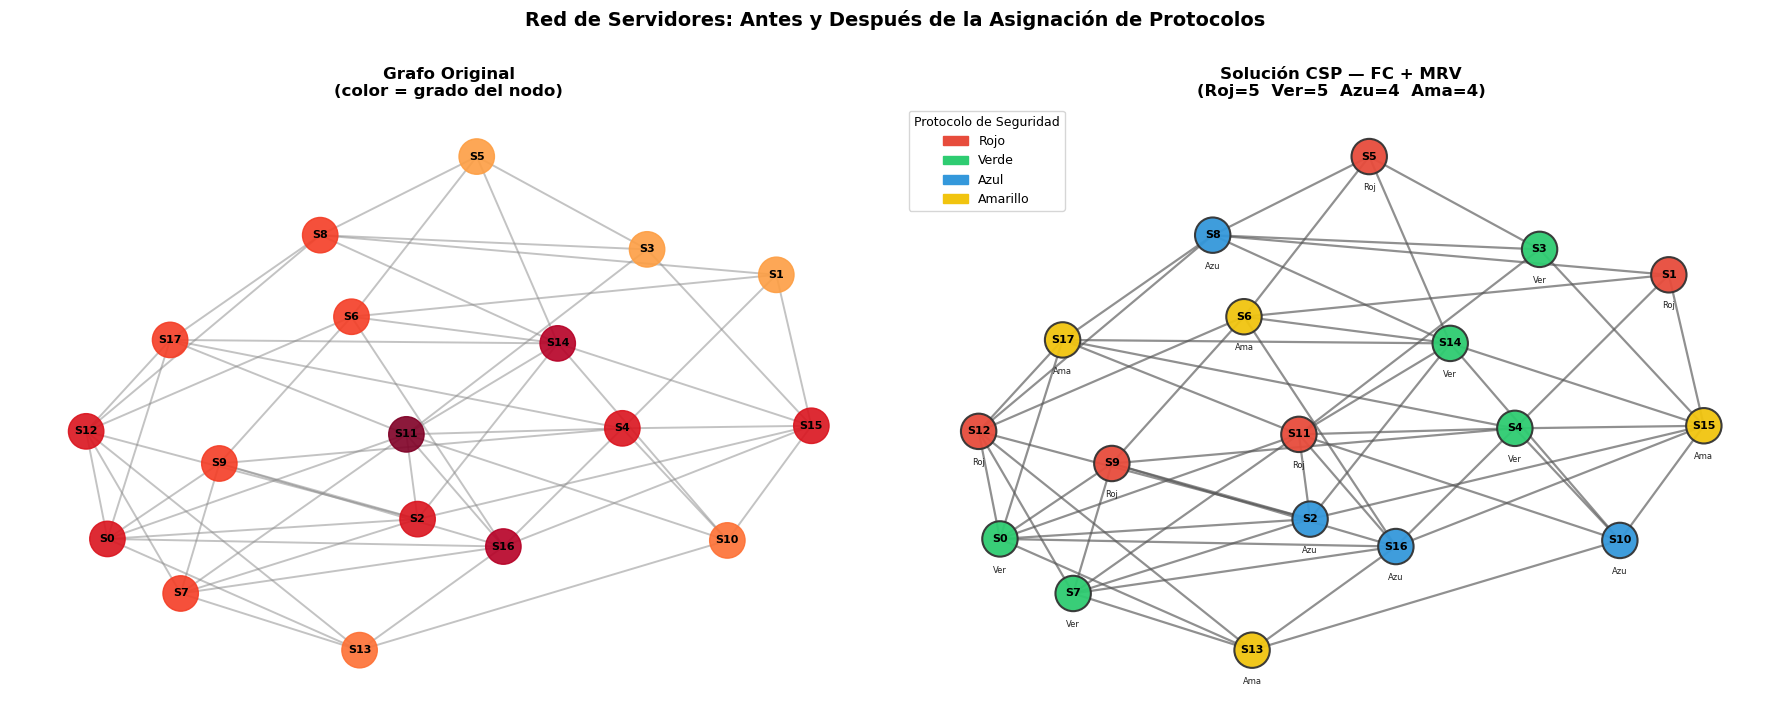

In [44]:
COLOR_MAP = {
    'Rojo':     '#e74c3c',
    'Verde':    '#2ecc71',
    'Azul':     '#3498db',
    'Amarillo': '#f1c40f',
}

def visualizar_grafo_solucion(G, solucion, pos, titulo="Solución CSP"):
    """
    Dibuja el grafo con nodos coloreados según el protocolo asignado.
    Las aristas se dibujan más gruesas para mostrar que los vecinos
    tienen colores distintos (restricción satisfecha).
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # ── Panel izquierdo: grafo original con layout de referencia ──────────────
    grados = dict(G.degree())
    max_grado = max(grados.values())
    cmap = plt.get_cmap("YlOrRd")
    colores_grado = [cmap(grados[n] / max_grado) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=colores_grado, node_size=650,
                           ax=axes[0], alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color='#888888', width=1.4,
                           alpha=0.5, ax=axes[0])
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=axes[0])
    axes[0].set_title("Grafo Original\n(color = grado del nodo)", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # ── Panel derecho: solución con protocolos ────────────────────────────────
    colores_sol = [COLOR_MAP[solucion[n]] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=colores_sol, node_size=650,
                           ax=axes[1], alpha=0.95,
                           linewidths=1.5, edgecolors='#333333')
    nx.draw_networkx_edges(G, pos, edge_color='#555555', width=1.6,
                           alpha=0.65, ax=axes[1])
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=axes[1])

    # Mostrar el protocolo asignado debajo de cada nodo
    etiquetas_protocolo = {n: solucion[n][:3] for n in G.nodes()}  # "Roj", "Ver"...
    pos_abajo = {n: (x, y - 0.12) for n, (x, y) in pos.items()}
    nx.draw_networkx_labels(G, pos_abajo, labels=etiquetas_protocolo,
                            font_size=6, font_color='#222222', ax=axes[1])

    # Leyenda de protocolos
    parches = [mpatches.Patch(color=c, label=p, linewidth=1)
               for p, c in COLOR_MAP.items()]
    axes[1].legend(handles=parches, title="Protocolo de Seguridad",
                   loc='upper left', fontsize=9, title_fontsize=9)

    # Distribución de protocolos
    conteo = {p: sum(1 for v in solucion.values() if v == p) for p in PROTOCOLOS}
    info = "  ".join([f"{p[:3]}={conteo[p]}" for p in PROTOCOLOS])
    axes[1].set_title(f"Solución CSP — {titulo}\n({info})", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle("Red de Servidores: Antes y Después de la Asignación de Protocolos",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Usar la solución de FC + MRV (la más eficiente)
solucion_final = solucion_mrv if solucion_mrv else solucion_fc if solucion_fc else solucion_bp
algoritmo_usado = "FC + MRV" if solucion_mrv else ("FC" if solucion_fc else "Backtracking Puro")

visualizar_grafo_solucion(G, solucion_final, pos, titulo=algoritmo_usado)

## Task 2 - Defensa Contra Adversarios (Juegos Adversariales)

### 1. Contexto del Juego

La red de servidores configurada en **Task 1** está operativa y correctamente protegida con protocolos de seguridad. Sin embargo, un atacante ha penetrado el sistema. Ahora se modela la defensa como un **juego adversarial por turnos** de suma cero.

---

#### Jugadores

| Jugador | Rol | Objetivo |
|---------|-----|----------|
| **MAX** (Nosotros) | Defensor | Maximizar el valor total controlado |
| **MIN** (Hacker) | Atacante | Minimizar el valor que controlamos |

#### Mecánica

- Cada nodo de la red tiene un **valor estratégico** aleatorio (1-100).
- Los jugadores inician en nodos separados y se expanden **capturando nodos adyacentes** a su territorio.
- El juego termina cuando todos los nodos están capturados o ningún jugador puede moverse.
- **Puntaje final:** $\text{Score} = \sum V_{\text{MAX}} - \sum V_{\text{MIN}}$

### 2. Generar Grafo + Valores Aleatorios

=== Configuración del Juego Adversarial ===
  Nodos: 18, Aristas: 56
  MAX (Defensor) inicia en: S7 (valor=99)
  MIN (Atacante) inicia en: S1 (valor=25)
  Distancia entre inicio MAX y MIN: 3 saltos

  Valores por nodo:
    S0:  51
    S1:  25
    S2:  43
    S3:  24
    S4:  81
    S5:   2
    S6:  68
    S7:  99
    S8:  90
    S9:   2
    S10:  44
    S11:  88
    S12:  60
    S13:  18
    S14:  29
    S15:  16
    S16:  89
    S17:  18


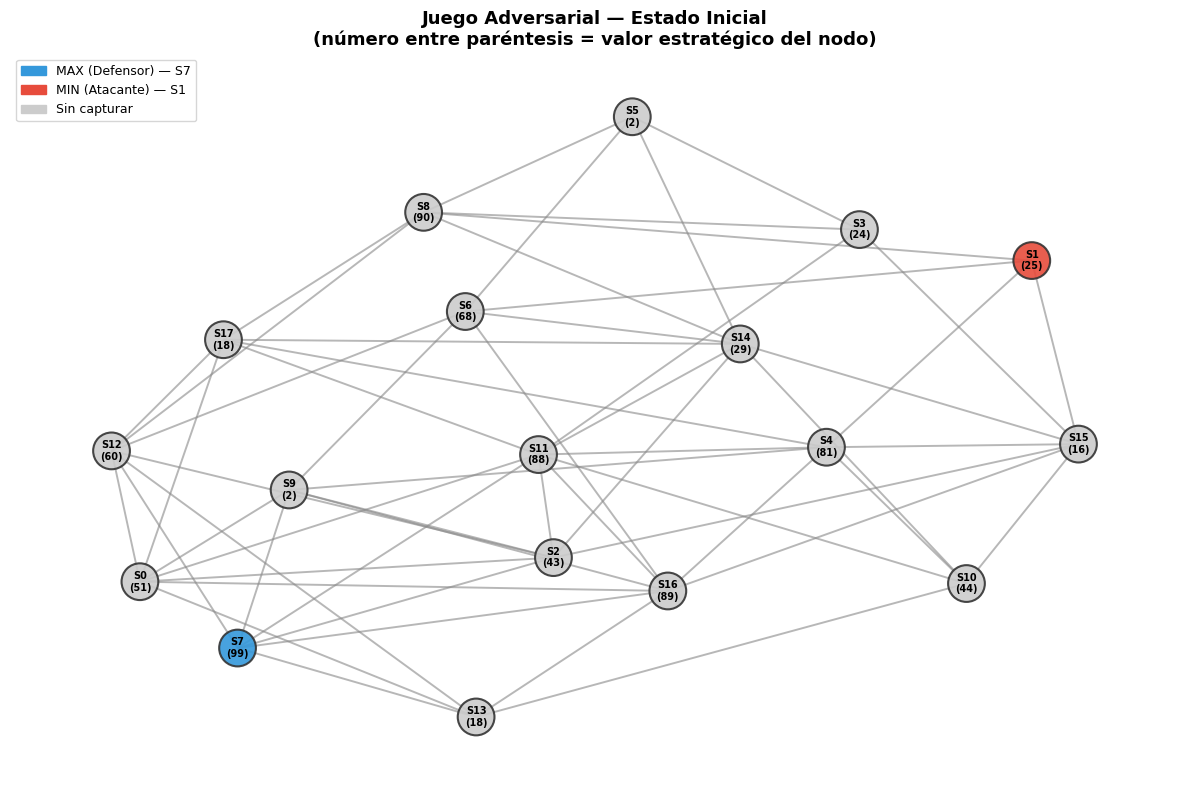

In [45]:
# ── Asignar valores estratégicos aleatorios a cada nodo ────────────────────────
random.seed(88)
node_values = {nodo: random.randint(1, 100) for nodo in G.nodes()}

# ── Posiciones iniciales ──────────────────────────────────────────────────────
# MAX (Defensor): nodo con mayor valor estratégico
max_start = max(G.nodes(), key=lambda n: (node_values[n], G.degree(n)))

# MIN (Atacante): nodo más lejano topológicamente de MAX
shortest_paths = dict(nx.shortest_path_length(G, source=max_start))
min_start = max(
    [n for n in G.nodes() if n != max_start],
    key=lambda n: (shortest_paths[n], node_values[n])
)

print("=== Configuración del Juego Adversarial ===")
print(f"  Nodos: {G.number_of_nodes()}, Aristas: {G.number_of_edges()}")
print(f"  MAX (Defensor) inicia en: {max_start} (valor={node_values[max_start]})")
print(f"  MIN (Atacante) inicia en: {min_start} (valor={node_values[min_start]})")
print(f"  Distancia entre inicio MAX y MIN: {shortest_paths[min_start]} saltos")
print(f"\n  Valores por nodo:")
for nodo in sorted(G.nodes(), key=lambda n: int(n[1:])):
    print(f"    {nodo}: {node_values[nodo]:>3}")

# ── Visualización del grafo con valores y posiciones iniciales ────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Colores: azul=MAX, rojo=MIN, gris=sin capturar
colores_nodos = []
for n in G.nodes():
    if n == max_start:
        colores_nodos.append('#3498db')  # azul
    elif n == min_start:
        colores_nodos.append('#e74c3c')  # rojo
    else:
        colores_nodos.append('#cccccc')  # gris

nx.draw_networkx_nodes(G, pos, node_color=colores_nodos, node_size=700,
                       ax=ax, alpha=0.9, linewidths=1.5, edgecolors='#333333')
nx.draw_networkx_edges(G, pos, edge_color='#888888', width=1.4, alpha=0.6, ax=ax)

# Etiquetas con nombre y valor
labels = {n: f"{n}\n({node_values[n]})" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_weight='bold', ax=ax)

parches = [
    mpatches.Patch(color='#3498db', label=f'MAX (Defensor) — {max_start}'),
    mpatches.Patch(color='#e74c3c', label=f'MIN (Atacante) — {min_start}'),
    mpatches.Patch(color='#cccccc', label='Sin capturar'),
]
ax.legend(handles=parches, loc='upper left', fontsize=9)
ax.set_title("Juego Adversarial — Estado Inicial\n"
             "(número entre paréntesis = valor estratégico del nodo)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 3. Clase GameState

In [46]:
class GameState:
    """
    Representa el estado del juego adversarial de captura de territorio.

    Atributos:
        graph       : Referencia al grafo NetworkX (compartida, inmutable).
        node_values : Dict {nodo: valor} con valores 1-100 (compartida, inmutable).
        max_nodes   : frozenset de nodos controlados por MAX (Defensor).
        min_nodes   : frozenset de nodos controlados por MIN (Atacante).
        is_max_turn : bool, True si es turno de MAX.
    """

    def __init__(self, graph, node_values, max_nodes, min_nodes, is_max_turn):
        self.graph = graph
        self.node_values = node_values
        self.max_nodes = frozenset(max_nodes)
        self.min_nodes = frozenset(min_nodes)
        self.is_max_turn = is_max_turn

    def get_moves(self, for_max=None):
        """
        Retorna la lista de nodos capturables por el jugador indicado.
        Un nodo es capturable si:
          1. No está capturado por ningún jugador.
          2. Es adyacente a al menos un nodo que el jugador controla.
        """
        if for_max is None:
            for_max = self.is_max_turn
        player_nodes = self.max_nodes if for_max else self.min_nodes
        captured = self.max_nodes | self.min_nodes
        moves = set()
        for nodo in player_nodes:
            for vecino in self.graph.neighbors(nodo):
                if vecino not in captured:
                    moves.add(vecino)
        return list(moves)

    def apply_move(self, move):
        """Retorna un nuevo GameState con el movimiento aplicado y turno cambiado."""
        if self.is_max_turn:
            return GameState(self.graph, self.node_values,
                             self.max_nodes | {move}, self.min_nodes,
                             not self.is_max_turn)
        else:
            return GameState(self.graph, self.node_values,
                             self.max_nodes, self.min_nodes | {move},
                             not self.is_max_turn)

    def is_terminal(self):
        """El juego termina cuando todos los nodos están capturados o no hay movimientos."""
        if len(self.max_nodes) + len(self.min_nodes) == len(self.graph.nodes()):
            return True
        return len(self.get_moves()) == 0

    def utility(self):
        """Utilidad terminal: diferencia de valor controlado."""
        v_max = sum(self.node_values[n] for n in self.max_nodes)
        v_min = sum(self.node_values[n] for n in self.min_nodes)
        return v_max - v_min

    def __repr__(self):
        return (f"GameState(MAX={sorted(self.max_nodes)}, MIN={sorted(self.min_nodes)}, "
                f"turno={'MAX' if self.is_max_turn else 'MIN'})")


# Verificar con un estado de prueba
test_state = GameState(G, node_values, {max_start}, {min_start}, True)
print(f"Estado de prueba: {test_state}")
print(f"  Movimientos de MAX: {sorted(test_state.get_moves(for_max=True))}")
print(f"  Movimientos de MIN: {sorted(test_state.get_moves(for_max=False))}")
print(f"  ¿Terminal?: {test_state.is_terminal()}")
print(f"  Utilidad: {test_state.utility()}")

Estado de prueba: GameState(MAX=['S7'], MIN=['S1'], turno=MAX)
  Movimientos de MAX: ['S11', 'S12', 'S13', 'S16', 'S2', 'S9']
  Movimientos de MIN: ['S15', 'S4', 'S6', 'S8']
  ¿Terminal?: False
  Utilidad: 74


### 4. Algoritmo Minimax Puro

Minimax explora el árbol de juego completo hasta una profundidad límite, alternando entre MAX (maximiza) y MIN (minimiza):

$$V(s) = \begin{cases} \text{Eval}(s) & \text{si } s \text{ es terminal o profundidad límite} \\ \max_{a} V(\text{resultado}(s, a)) & \text{si es turno de MAX} \\ \min_{a} V(\text{resultado}(s, a)) & \text{si es turno de MIN} \end{cases}$$

In [47]:
# Contador global de nodos expandidos por Minimax
nodes_expanded_minimax = 0

def minimax(state, depth, depth_max):
    """
    Algoritmo Minimax con profundidad limitada.

    Explora el árbol de juego completo hasta depth_max, alternando
    entre MAX (maximiza) y MIN (minimiza). Usa evaluate() como
    función heurística cuando alcanza el límite de profundidad.

    Args:
        state     : GameState actual.
        depth     : Profundidad actual (inicia en 0).
        depth_max : Profundidad máxima de búsqueda.

    Returns:
        (valor, mejor_movimiento): Tupla con el valor minimax y el movimiento óptimo.
    """
    global nodes_expanded_minimax
    nodes_expanded_minimax += 1

    # Caso base: estado terminal o límite de profundidad
    if state.is_terminal() or depth >= depth_max:
        return evaluate(state), None

    moves = state.get_moves()
    if not moves:
        return evaluate(state), None

    # Ordenar movimientos por valor del nodo (consistente con alfa-beta)
    if state.is_max_turn:
        moves.sort(key=lambda m: state.node_values[m], reverse=True)
    else:
        moves.sort(key=lambda m: state.node_values[m])

    best_move = None

    if state.is_max_turn:
        best_value = float('-inf')
        for move in moves:
            child = state.apply_move(move)
            val, _ = minimax(child, depth + 1, depth_max)
            if val > best_value:
                best_value = val
                best_move = move
    else:
        best_value = float('inf')
        for move in moves:
            child = state.apply_move(move)
            val, _ = minimax(child, depth + 1, depth_max)
            if val < best_value:
                best_value = val
                best_move = move

    return best_value, best_move


print("Función minimax() definida correctamente.")
print("Nota: requiere evaluate() (definida en la siguiente celda) para ejecutarse.")

Función minimax() definida correctamente.
Nota: requiere evaluate() (definida en la siguiente celda) para ejecutarse.


### 5. Función de Evaluación Heurística - Eval(s)

In [48]:
def eval_simple(state):
    """
    Evaluación simple: diferencia de valor controlado.
    Eval_simple(s) = V_MAX - V_MIN
    """
    v_max = sum(state.node_values[n] for n in state.max_nodes)
    v_min = sum(state.node_values[n] for n in state.min_nodes)
    return v_max - v_min


def eval_intermediate(state):
    """
    Evaluación intermedia: valor + movilidad.
    Eval_mid(s) = (V_MAX - V_MIN) + w_mob * (M_MAX - M_MIN)

    La movilidad mide la flexibilidad táctica: más movimientos
    posibles = más opciones para capturar nodos valiosos.
    """
    val_diff = eval_simple(state)
    m_max = len(state.get_moves(for_max=True))
    m_min = len(state.get_moves(for_max=False))
    W_MOB = 3.0
    return val_diff + W_MOB * (m_max - m_min)


def evaluate(state):
    """
    Evaluación avanzada: valor + movilidad + potencial futuro.

    Eval(s) = w_val*(V_MAX - V_MIN) + w_mob*(M_MAX - M_MIN) + w_pot*(P_MAX - P_MIN)

    Componentes:
      V_x : Valor total de nodos controlados por jugador x.
      M_x : Número de movimientos legales para jugador x (movilidad).
      P_x : Valor total de nodos sin capturar adyacentes al territorio de x (potencial).

    Pesos:
      w_val = 1.0 : El valor controlado es el objetivo directo.
      w_mob = 3.0 : Cada movimiento extra equivale a ~3 puntos de valor.
      w_pot = 0.5 : El potencial futuro se descuenta (no está capturado aún).
    """
    captured = state.max_nodes | state.min_nodes

    # Componente de valor
    V_max = sum(state.node_values[n] for n in state.max_nodes)
    V_min = sum(state.node_values[n] for n in state.min_nodes)

    # Componente de movilidad
    M_max = len(state.get_moves(for_max=True))
    M_min = len(state.get_moves(for_max=False))

    # Componente de potencial: valor de nodos alcanzables en un movimiento
    def potencial(player_nodes):
        frontera = set()
        for nodo in player_nodes:
            for vecino in state.graph.neighbors(nodo):
                if vecino not in captured:
                    frontera.add(vecino)
        return sum(state.node_values[n] for n in frontera)

    P_max = potencial(state.max_nodes)
    P_min = potencial(state.min_nodes)

    W_VAL = 1.0
    W_MOB = 3.0
    W_POT = 0.5

    return W_VAL * (V_max - V_min) + W_MOB * (M_max - M_min) + W_POT * (P_max - P_min)


# Demostrar las tres evaluaciones sobre el estado inicial
test_state = GameState(G, node_values, {max_start}, {min_start}, True)
print("Evaluación del estado inicial:")
print(f"  eval_simple       : {eval_simple(test_state):.1f}")
print(f"  eval_intermediate : {eval_intermediate(test_state):.1f}")
print(f"  evaluate (avanzada): {evaluate(test_state):.1f}")

Evaluación del estado inicial:
  eval_simple       : 74.0
  eval_intermediate : 80.0
  evaluate (avanzada): 102.5


### 6. Análisis Matemático de la Función de Evaluación $\text{Eval}(s)$

#### Definición Formal

La función de evaluación heurística combina tres componentes estratégicos en una suma ponderada:

$$\text{Eval}(s) = w_{\text{val}} \cdot (V_{\text{MAX}} - V_{\text{MIN}}) + w_{\text{mob}} \cdot (M_{\text{MAX}} - M_{\text{MIN}}) + w_{\text{pot}} \cdot (P_{\text{MAX}} - P_{\text{MIN}})$$

donde:

| Componente | Definición | Interpretación |
|------------|-----------|----------------|
| $V_x = \displaystyle\sum_{n \in \text{nodos}_x} \text{valor}(n)$ | Valor controlado | Objetivo directo del juego |
| $M_x = \|\text{movimientos}(x)\|$ | Movilidad | Flexibilidad táctica |
| $P_x = \displaystyle\sum_{n \in \text{frontera}(x)} \text{valor}(n)$ | Potencial | Valor alcanzable en 1 turno |

con $\text{frontera}(x) = \{n \notin \text{capturados} : \exists v \in \text{nodos}_x, (v,n) \in E\}$.

---

#### Justificación de los Pesos

| Peso | Valor | Justificación |
|------|-------|---------------|
| $w_{\text{val}} = 1.0$ | Referencia | Es la métrica de victoria directa; define la escala. |
| $w_{\text{mob}} = 3.0$ | Alto | Cada movimiento adicional da acceso a ~1 nodo con valor promedio ~50. El peso de 3.0 refleja que la movilidad tiene valor táctico más allá de un solo nodo: permite *elegir* los mejores nodos. |
| $w_{\text{pot}} = 0.5$ | Descuento | Los nodos de la frontera aún no están capturados (el oponente puede tomarlos primero). Se descuenta al 50% para reflejar esta incertidumbre. |

---

#### ¿Por qué es una buena aproximación?

1. Si MAX controla más valor, tiene más movilidad y mejor potencial, entonces $\text{Eval}(s)$ crece. Esto se alinea con la utilidad terminal real.

2. Los tres componentes capturan dimensiones independientes del estado:
   - $V$ mide el **pasado** (lo ya ganado).
   - $M$ mide el **presente** (opciones tácticas inmediatas).
   - $P$ mide el **futuro** (oportunidades estratégicas).

3. En un estado terminal ($M_x = 0$, $P_x = 0$), la evaluación se reduce a $\text{Eval}(s) = V_{\text{MAX}} - V_{\text{MIN}} = \text{utilidad}(s)$, lo cual es exacto.

4. Comparado con `eval_simple` (solo valor), la función avanzada diferencia entre estados que tienen el mismo valor controlado pero diferente posición estratégica, guiando la búsqueda hacia posiciones más favorables.

### 7. Poda Alfa-Beta

Optimiza Minimax manteniendo dos cotas:

- $\alpha$: mejor valor garantizado para MAX (cota inferior)
- $\beta$: mejor valor garantizado para MIN (cota superior)

Cuando $\alpha \geq \beta$, se poda la rama (no puede mejorar el resultado).

In [50]:
# Contadores globales para Alfa-Beta
nodes_expanded_ab = 0
nodes_pruned_ab = 0

def alphabeta(state, depth, depth_max, alpha, beta):
    """
    Algoritmo Minimax con Poda Alfa-Beta.

    Optimización de Minimax que mantiene dos cotas:
      - alpha: mejor valor garantizado para MAX (cota inferior).
      - beta : mejor valor garantizado para MIN (cota superior).

    Cuando alpha >= beta, se poda la rama porque no puede mejorar
    el resultado para ningún jugador.

    Usa el MISMO ordenamiento de movimientos que minimax() para
    garantizar que retorna el mismo movimiento óptimo.

    Args:
        state     : GameState actual.
        depth     : Profundidad actual.
        depth_max : Profundidad máxima.
        alpha     : Cota inferior (mejor para MAX).
        beta      : Cota superior (mejor para MIN).

    Returns:
        (valor, mejor_movimiento)
    """
    global nodes_expanded_ab, nodes_pruned_ab
    nodes_expanded_ab += 1

    if state.is_terminal() or depth >= depth_max:
        return evaluate(state), None

    moves = state.get_moves()
    if not moves:
        return evaluate(state), None

    # Mismo ordenamiento que minimax
    if state.is_max_turn:
        moves.sort(key=lambda m: state.node_values[m], reverse=True)
    else:
        moves.sort(key=lambda m: state.node_values[m])

    best_move = None

    if state.is_max_turn:
        best_value = float('-inf')
        for i, move in enumerate(moves):
            child = state.apply_move(move)
            val, _ = alphabeta(child, depth + 1, depth_max, alpha, beta)
            if val > best_value:
                best_value = val
                best_move = move
            alpha = max(alpha, best_value)
            if alpha >= beta:
                # Podar: los movimientos restantes no se explorarán
                nodes_pruned_ab += len(moves) - (i + 1)
                break
    else:
        best_value = float('inf')
        for i, move in enumerate(moves):
            child = state.apply_move(move)
            val, _ = alphabeta(child, depth + 1, depth_max, alpha, beta)
            if val < best_value:
                best_value = val
                best_move = move
            beta = min(beta, best_value)
            if beta <= alpha:
                nodes_pruned_ab += len(moves) - (i + 1)
                break

    return best_value, best_move


print("Función alphabeta() definida correctamente.")

Función alphabeta() definida correctamente.


### 8. Funciones Auxilares

In [51]:
def run_minimax(state, depth_max=4):
    """Ejecuta Minimax y retorna resultados con métricas."""
    global nodes_expanded_minimax
    nodes_expanded_minimax = 0

    t0 = time.perf_counter()
    value, best_move = minimax(state, 0, depth_max)
    t1 = time.perf_counter()

    return {
        'algorithm': 'Minimax Puro',
        'value': value,
        'best_move': best_move,
        'nodes_expanded': nodes_expanded_minimax,
        'time_ms': (t1 - t0) * 1000
    }


def run_alphabeta(state, depth_max=4):
    """Ejecuta Alfa-Beta y retorna resultados con métricas."""
    global nodes_expanded_ab, nodes_pruned_ab
    nodes_expanded_ab = 0
    nodes_pruned_ab = 0

    t0 = time.perf_counter()
    value, best_move = alphabeta(state, 0, depth_max, float('-inf'), float('inf'))
    t1 = time.perf_counter()

    return {
        'algorithm': 'Alfa-Beta',
        'value': value,
        'best_move': best_move,
        'nodes_expanded': nodes_expanded_ab,
        'nodes_pruned': nodes_pruned_ab,
        'time_ms': (t1 - t0) * 1000
    }


def print_results(results):
    """Imprime los resultados de un algoritmo de forma legible."""
    print(f"  Algoritmo        : {results['algorithm']}")
    print(f"  Valor minimax    : {results['value']:.2f}")
    print(f"  Mejor movimiento : {results['best_move']} (valor={node_values[results['best_move']]})")
    print(f"  Nodos expandidos : {results['nodes_expanded']}")
    if 'nodes_pruned' in results:
        print(f"  Nodos podados    : {results['nodes_pruned']}")
    print(f"  Tiempo           : {results['time_ms']:.3f} ms")


print("Funciones de ejecución definidas: run_minimax(), run_alphabeta(), print_results()")

Funciones de ejecución definidas: run_minimax(), run_alphabeta(), print_results()


### 9. Prueba de Tiempo y Nodos: Minimax Puro

In [52]:
DEPTH_MAX = 4

# Crear estado inicial
initial_state = GameState(
    graph=G,
    node_values=node_values,
    max_nodes={max_start},
    min_nodes={min_start},
    is_max_turn=True
)

print("=== Estado Inicial ===")
print(f"  MAX (Defensor) controla: {max_start} (valor={node_values[max_start]})")
print(f"  MIN (Atacante) controla: {min_start} (valor={node_values[min_start]})")
print(f"  Nodos sin capturar: {G.number_of_nodes() - 2}")
print(f"  Movimientos posibles MAX: {sorted(initial_state.get_moves(for_max=True))}")
print(f"  Movimientos posibles MIN: {sorted(initial_state.get_moves(for_max=False))}")
print(f"  Profundidad máxima: {DEPTH_MAX}")
print()

print("=== Minimax Puro ===")
results_minimax = run_minimax(initial_state, DEPTH_MAX)
print_results(results_minimax)

=== Estado Inicial ===
  MAX (Defensor) controla: S7 (valor=99)
  MIN (Atacante) controla: S1 (valor=25)
  Nodos sin capturar: 16
  Movimientos posibles MAX: ['S11', 'S12', 'S13', 'S16', 'S2', 'S9']
  Movimientos posibles MIN: ['S15', 'S4', 'S6', 'S8']
  Profundidad máxima: 4

=== Minimax Puro ===
  Algoritmo        : Minimax Puro
  Valor minimax    : 126.50
  Mejor movimiento : S11 (valor=88)
  Nodos expandidos : 1663
  Tiempo           : 51.857 ms


### 10. Prueba de Tiempo y Nodos: Minimax con Poda Alfa-Beta

In [53]:
print("=== Alfa-Beta ===")
results_ab = run_alphabeta(initial_state, DEPTH_MAX)
print_results(results_ab)

# ── Validación: ambos algoritmos deben encontrar el mismo resultado ───────────
print()
print("=" * 55)
print("VERIFICACIÓN DE RESULTADOS")
print("=" * 55)

values_match = abs(results_minimax['value'] - results_ab['value']) < 1e-9
moves_match = results_minimax['best_move'] == results_ab['best_move']

print(f"  Valor minimax coincide : {'SÍ' if values_match else 'NO'}"
      f" ({results_minimax['value']:.2f} vs {results_ab['value']:.2f})")
print(f"  Movimiento coincide   : {'SÍ' if moves_match else 'NO'}"
      f" ({results_minimax['best_move']} vs {results_ab['best_move']})")

reduction_nodes = (1 - results_ab['nodes_expanded'] / results_minimax['nodes_expanded']) * 100
reduction_time = (1 - results_ab['time_ms'] / results_minimax['time_ms']) * 100
print(f"  Reducción de nodos    : {reduction_nodes:.1f}%")
print(f"  Reducción de tiempo   : {reduction_time:.1f}%")

assert values_match, "ERROR: Los valores minimax no coinciden"
assert moves_match, "ERROR: Los movimientos óptimos no coinciden"
print("\nAmbas verificaciones pasaron correctamente.")

=== Alfa-Beta ===
  Algoritmo        : Alfa-Beta
  Valor minimax    : 126.50
  Mejor movimiento : S11 (valor=88)
  Nodos expandidos : 335
  Nodos podados    : 397
  Tiempo           : 10.691 ms

VERIFICACIÓN DE RESULTADOS
  Valor minimax coincide : SÍ (126.50 vs 126.50)
  Movimiento coincide   : SÍ (S11 vs S11)
  Reducción de nodos    : 79.9%
  Reducción de tiempo   : 79.4%

Ambas verificaciones pasaron correctamente.


### 11. Análisis de Desempeño

#### Tabla Comparativa

In [54]:
# ── Tabla comparativa principal ────────────────────────────────────────────────
print("=" * 75)
print(f"{'Métrica':<28} {'Minimax Puro':>15} {'Alfa-Beta':>15} {'Reducción':>12}")
print("=" * 75)
print(f"{'Nodos expandidos':<28} {results_minimax['nodes_expanded']:>15,} {results_ab['nodes_expanded']:>15,} {reduction_nodes:>11.1f}%")
print(f"{'Nodos podados':<28} {'N/A':>15} {results_ab['nodes_pruned']:>15,} {'':>12}")
print(f"{'Tiempo (ms)':<28} {results_minimax['time_ms']:>15.3f} {results_ab['time_ms']:>15.3f} {reduction_time:>11.1f}%")
print(f"{'Valor minimax':<28} {results_minimax['value']:>15.2f} {results_ab['value']:>15.2f} {'Iguales':>12}")
print(f"{'Mejor movimiento':<28} {results_minimax['best_move']:>15} {results_ab['best_move']:>15} {'Iguales':>12}")
print("=" * 75)

# ── Comparación multi-profundidad ─────────────────────────────────────────────
print("\n\n=== Comparación por Profundidad (1 a 4) ===\n")
depths = [1, 2, 3, 4]
mm_data = []
ab_data = []

for d in depths:
    r_mm = run_minimax(initial_state, d)
    r_ab = run_alphabeta(initial_state, d)
    mm_data.append(r_mm)
    ab_data.append(r_ab)

print(f"{'Prof':<6} {'MM Nodos':>10} {'AB Nodos':>10} {'Reducción':>10} "
      f"{'MM Tiempo':>12} {'AB Tiempo':>12} {'MM Mov':>8} {'AB Mov':>8} {'Mismo?':>8}")
print("-" * 88)
for i, d in enumerate(depths):
    red = (1 - ab_data[i]['nodes_expanded'] / mm_data[i]['nodes_expanded']) * 100
    mismo = 'Sí' if mm_data[i]['best_move'] == ab_data[i]['best_move'] else 'No'
    print(f"  {d:<4} {mm_data[i]['nodes_expanded']:>10,} {ab_data[i]['nodes_expanded']:>10,} {red:>9.1f}% "
          f"{mm_data[i]['time_ms']:>11.3f} {ab_data[i]['time_ms']:>11.3f} "
          f"{mm_data[i]['best_move']:>8} {ab_data[i]['best_move']:>8} {mismo:>8}")

Métrica                         Minimax Puro       Alfa-Beta    Reducción
Nodos expandidos                       1,663             335        79.9%
Nodos podados                            N/A             397             
Tiempo (ms)                           51.857          10.691        79.4%
Valor minimax                         126.50          126.50      Iguales
Mejor movimiento                         S11             S11      Iguales


=== Comparación por Profundidad (1 a 4) ===

Prof     MM Nodos   AB Nodos  Reducción    MM Tiempo    AB Tiempo   MM Mov   AB Mov   Mismo?
----------------------------------------------------------------------------------------
  1             7          7       0.0%       0.185       0.108      S11      S11       Sí
  2            31         20      35.5%       0.478       0.310      S11      S11       Sí
  3           230        126      45.2%       4.569       2.400      S16      S16       Sí
  4         1,663        335      79.9%      45.374   

#### Gráficos Comparativos (nodos, tiempo)

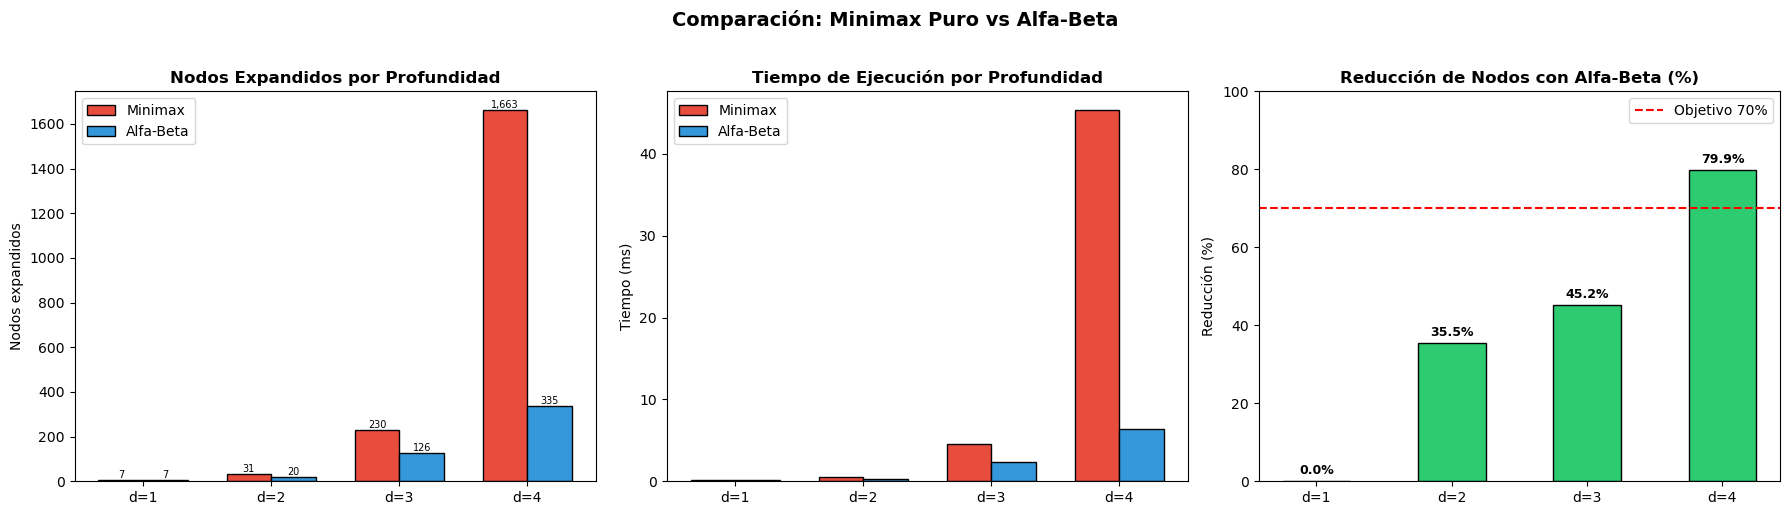

In [55]:
# ── Datos para gráficos ────────────────────────────────────────────────────────
mm_nodes_list = [r['nodes_expanded'] for r in mm_data]
ab_nodes_list = [r['nodes_expanded'] for r in ab_data]
mm_time_list  = [r['time_ms'] for r in mm_data]
ab_time_list  = [r['time_ms'] for r in ab_data]
reductions    = [(1 - ab/mm) * 100 for mm, ab in zip(mm_nodes_list, ab_nodes_list)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(depths))
w = 0.35

# ── Gráfico 1: Nodos expandidos ──────────────────────────────────────────────
bars1 = axes[0].bar(x - w/2, mm_nodes_list, w, label='Minimax', color='#e74c3c', edgecolor='black')
bars2 = axes[0].bar(x + w/2, ab_nodes_list, w, label='Alfa-Beta', color='#3498db', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'd={d}' for d in depths])
axes[0].set_title('Nodos Expandidos por Profundidad', fontweight='bold')
axes[0].set_ylabel('Nodos expandidos')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)

# ── Gráfico 2: Tiempo de ejecución ───────────────────────────────────────────
bars3 = axes[1].bar(x - w/2, mm_time_list, w, label='Minimax', color='#e74c3c', edgecolor='black')
bars4 = axes[1].bar(x + w/2, ab_time_list, w, label='Alfa-Beta', color='#3498db', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'd={d}' for d in depths])
axes[1].set_title('Tiempo de Ejecución por Profundidad', fontweight='bold')
axes[1].set_ylabel('Tiempo (ms)')
axes[1].legend()

# ── Gráfico 3: Porcentaje de reducción ───────────────────────────────────────
bars5 = axes[2].bar(x, reductions, 0.5, color='#2ecc71', edgecolor='black')
axes[2].axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='Objetivo 70%')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'd={d}' for d in depths])
axes[2].set_title('Reducción de Nodos con Alfa-Beta (%)', fontweight='bold')
axes[2].set_ylabel('Reducción (%)')
axes[2].set_ylim(0, 100)
axes[2].legend()
for bar, r in zip(bars5, reductions):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{r:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparación: Minimax Puro vs Alfa-Beta', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Interpretación

Minimax Puro y Alfa-Beta retornan **el mismo valor minimax y el mismo movimiento óptimo** para todas las profundidades probadas (1-4). Esto confirma que la poda no elimina ramas que podrían contener la solución óptima, solo descarta aquellas que son demostrablemente subóptimas.

Además, Alfa-Beta logra una **reducción significativa** tanto en nodos expandidos como en tiempo de ejecución. El ordenamiento de movimientos por valor del nodo (descendente para MAX, ascendente para MIN) es clave para maximizar la poda: al explorar primero los movimientos más prometedores, las cotas $\alpha$ y $\beta$ se ajustan rápidamente, lo que permite podar más ramas.